In [1]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import SGD, Adam

/opt/homebrew/lib/python3.11/site-packages/keras/src/export/tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


In [2]:
np.random.seed(42)
tf.random.set_seed(42)

In [3]:
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.mnist.load_data()

In [4]:
print(X_train.shape)  # (60000, 28, 28)
print(y_train.shape)  # (60000,)

(60000, 28, 28)
(60000,)


In [5]:
X_train = X_train.reshape(-1, 784)
X_test = X_test.reshape(-1, 784)

In [6]:
X_train = X_train / 255.0
X_test = X_test / 255.0

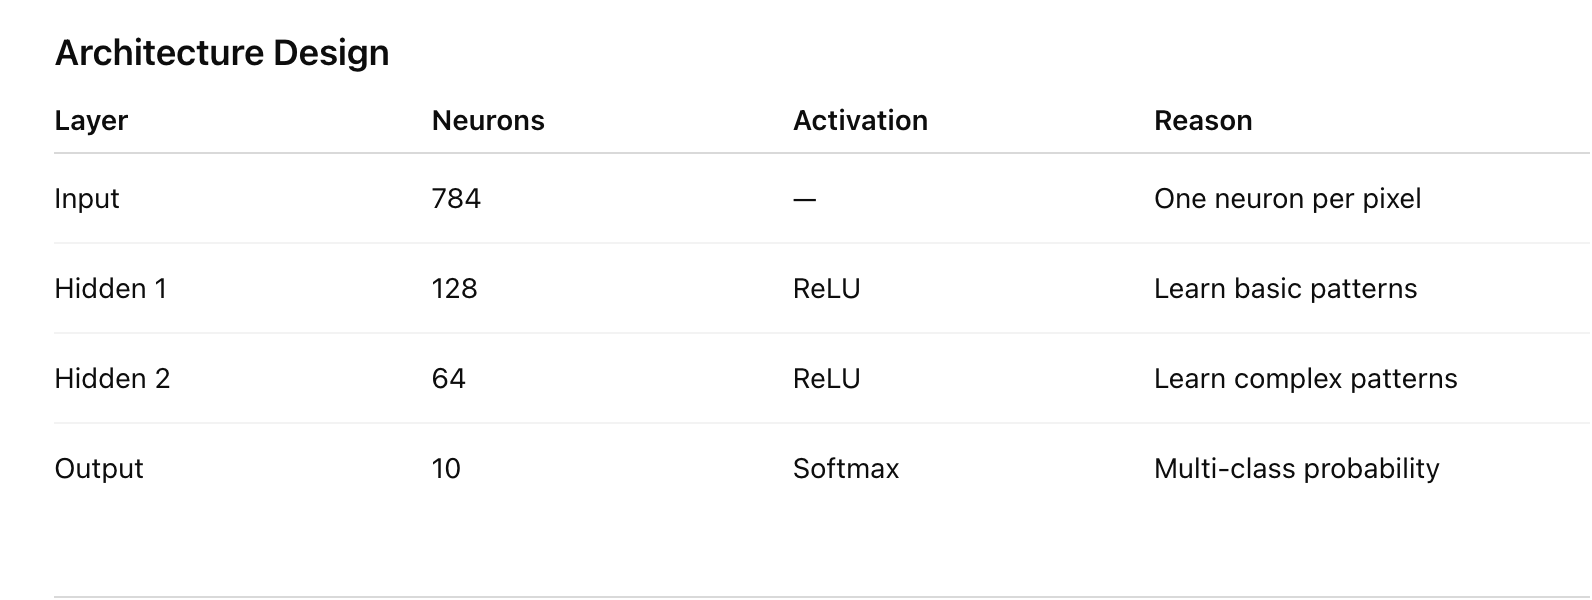

In [7]:
model = Sequential([
    Dense(128, activation='relu', input_shape=(784,)),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])


/opt/homebrew/lib/python3.11/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [8]:
sample_preds = model(X_train[:5])
print(sample_preds)

tf.Tensor(
[[0.09429864 0.14642356 0.06081823 0.07196965 0.11025497 0.1448456
  0.15381104 0.08781344 0.06666967 0.06309518]
 [0.10618231 0.09850381 0.06017102 0.13253596 0.0720826  0.14196166
  0.1593875  0.07099622 0.12038387 0.03779504]
 [0.09716446 0.10166986 0.12288979 0.12585948 0.08423687 0.09766147
  0.11603342 0.09441708 0.08893931 0.07112829]
 [0.13069098 0.08200125 0.06795415 0.14042485 0.09757957 0.10243481
  0.1291204  0.0932712  0.10811476 0.04840808]
 [0.10936082 0.11360344 0.08999283 0.11878733 0.08971274 0.13424866
  0.11874479 0.08011825 0.09521502 0.05021609]], shape=(5, 10), dtype=float32)


In [9]:
loss = 'sparse_categorical_crossentropy'

In [10]:
optimizer = Adam(learning_rate=0.0001)

In [11]:
model.compile(
    optimizer=optimizer,
    loss=loss,
    metrics=['accuracy']
)


In [12]:
(60000-6000)/128

421.875

In [13]:
60000/128

468.75

In [14]:
history = model.fit(
    X_train,
    y_train,
    epochs=25,
    batch_size=128,
    validation_split=0.2
)


Epoch 1/25
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7347 - loss: 1.0694 - val_accuracy: 0.8866 - val_loss: 0.4681
Epoch 2/25
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8931 - loss: 0.4006 - val_accuracy: 0.9145 - val_loss: 0.3212
Epoch 3/25
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9137 - loss: 0.3104 - val_accuracy: 0.9262 - val_loss: 0.2718
Epoch 4/25
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9250 - loss: 0.2681 - val_accuracy: 0.9327 - val_loss: 0.2425
Epoch 5/25
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9325 - loss: 0.2396 - val_accuracy: 0.9387 - val_loss: 0.2216
Epoch 6/25
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9388 - loss: 0.2173 - val_accuracy: 0.9433 - val_loss: 0.2048
Epoch 7/25
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9441 - loss: 0.1990 - val_accuracy: 0.9470 - val_loss: 0.1908
Epoch 8/25
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9485 - loss: 0.1832 - val_accuracy: 0.

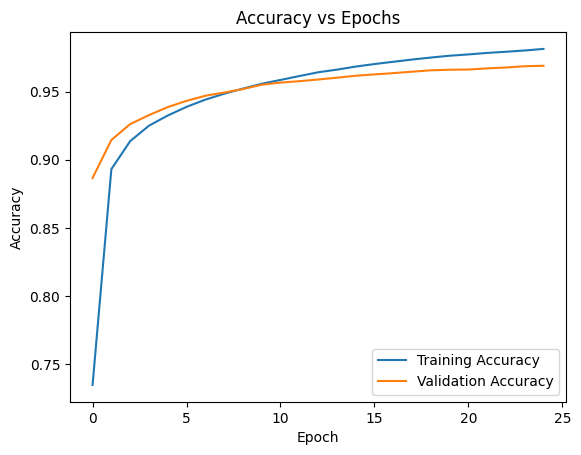

In [15]:
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Accuracy vs Epochs')
plt.show()


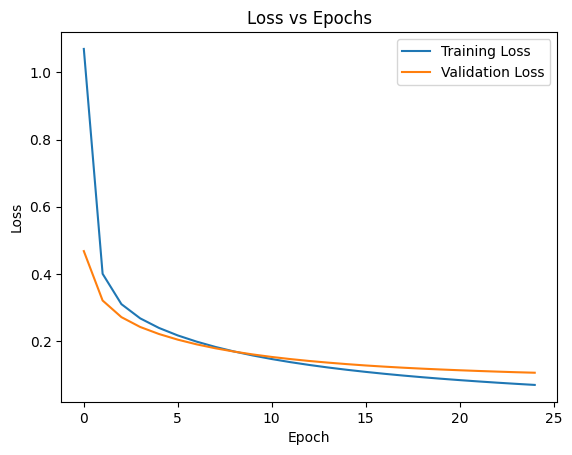

In [16]:
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Loss vs Epochs')
plt.show()


In [17]:
test_loss, test_accuracy = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9693 - loss: 0.0987
Test Accuracy: 96.93%
